# Model 1: Information Content of Congressional Trades

## Research Question
**¿Los trades de congresistas contienen información que mejora la predicción de retornos anormales más allá de la información pública de mercado?**

## Theoretical Framework (Grossman-Stiglitz 1980)
- Si los mercados son informativamente eficientes, la información pública ya está en los precios
- Solo la información **privada** puede generar retornos anormales predecibles

## Experimental Design
```
Modelo Base:     E[CAR] = f(X_market)
Modelo Ampliado: E[CAR] = f(X_market, X_congress)

Test: R²_OOS(Ampliado) > R²_OOS(Base) → Información privada
```

## Analysis Pipeline
1. Benchmark Comparison (múltiples modelos)
2. Statistical Tests (Clark-West, Diebold-Mariano)
3. Feature Importance
4. Subgroup Analysis
5. Temporal Analysis
---

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone
from scipy import stats
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("="*70)
print("MODEL 1: INFORMATION CONTENT OF CONGRESSIONAL TRADES")
print("="*70)

MODEL 1: INFORMATION CONTENT OF CONGRESSIONAL TRADES


In [2]:
# CONFIGURATION
INPUT_PATH = 'data/prediction_bases/panel_final_stock_month.parquet'
FEATURES_PATH = 'data/prediction_bases/feature_sets.json'
OUTPUT_DIR = 'Model_1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = 'ret_future_car30_ff3'
MIN_TRAIN_MONTHS = 36
SEED = 42
np.random.seed(SEED)

print(f"Target: {TARGET}")
print(f"Output: {OUTPUT_DIR}/")

Target: ret_future_car30_ff3
Output: Model_1/


## 1. Load Data

In [4]:
print("\n[1] LOADING DATA...")
panel = pd.read_parquet(INPUT_PATH)
print(f"    Panel shape: {panel.shape}")

with open(FEATURES_PATH, 'r') as f:
    feature_sets = json.load(f)
print(f"    Congress features: {len(feature_sets['congress'])}")
print(f"    Market features: {len(feature_sets['market'])}")


[1] LOADING DATA...
    Panel shape: (43381, 119)
    Congress features: 71
    Market features: 29


In [5]:
# Check target
print(f"\n    Target '{TARGET}':")
print(f"      Non-null: {panel[TARGET].notna().sum():,}")
print(f"      Mean: {panel[TARGET].mean():.4f}")
print(f"      Std: {panel[TARGET].std():.4f}")


    Target 'ret_future_car30_ff3':
      Non-null: 34,623
      Mean: -0.0013
      Std: 0.0914


In [6]:
# Prepare data
df = panel.dropna(subset=[TARGET]).copy()
print(f"\n    After dropping NaN: {len(df):,} obs")

if 'month_dt' not in df.columns:
    df['month_dt'] = pd.to_datetime(df['month'].astype(str))
df = df.sort_values('month_dt').reset_index(drop=True)

print(f"    Period: {df['month_dt'].min().strftime('%Y-%m')} to {df['month_dt'].max().strftime('%Y-%m')}")


    After dropping NaN: 34,623 obs
    Period: 2012-07 to 2024-12


## 2. Define Feature Sets

In [7]:
print("\n[2] DEFINING FEATURE SETS...")

FEATURES_MARKET = [c for c in feature_sets['market'] 
                   if c in df.columns and 'car_' not in c.lower()]
FEATURES_CONGRESS = [c for c in feature_sets['congress'] if c in df.columns]
FEATURES_ALL = FEATURES_MARKET + FEATURES_CONGRESS

# Core congress features
FEATURES_CONGRESS_CORE = [
    'cong_csi', 'cong_net', 'cong_info_ratio', 'cong_chair_ratio',
    'cong_avg_power_index', 'cong_senator_ratio', 'cong_coordinated_ratio',
    'cong_committee_coordinated_ratio', 'cong_avg_disclosure_delay',
    'cong_contrarian_ratio', 'cong_large_ratio', 'cong_unique_politicians'
]
FEATURES_CONGRESS_CORE = [c for c in FEATURES_CONGRESS_CORE if c in df.columns]

print(f"    FEATURES_MARKET: {len(FEATURES_MARKET)}")
print(f"    FEATURES_CONGRESS: {len(FEATURES_CONGRESS)}")
print(f"    FEATURES_CONGRESS_CORE: {len(FEATURES_CONGRESS_CORE)}")
print(f"    FEATURES_ALL: {len(FEATURES_ALL)}")


[2] DEFINING FEATURE SETS...
    FEATURES_MARKET: 29
    FEATURES_CONGRESS: 71
    FEATURES_CONGRESS_CORE: 12
    FEATURES_ALL: 100


In [8]:
# Fill missing values
for col in FEATURES_ALL:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
print("    Missing values filled with median")

    Missing values filled with median


## 3. Expanding Window CV Setup

In [9]:
print("\n[3] EXPANDING WINDOW CV...")

months = np.sort(df['month_dt'].unique())
print(f"    Total months: {len(months)}")
print(f"    Min training: {MIN_TRAIN_MONTHS}")
print(f"    Test months: {len(months) - MIN_TRAIN_MONTHS}")

def expanding_window_cv(df, months, min_train=36):
    splits = []
    for t in range(min_train, len(months)):
        train_idx = df[df['month_dt'].isin(months[:t])].index.tolist()
        test_idx = df[df['month_dt'] == months[t]].index.tolist()
        if train_idx and test_idx:
            splits.append((train_idx, test_idx))
    return splits

cv_splits = expanding_window_cv(df, months, MIN_TRAIN_MONTHS)
print(f"    CV splits: {len(cv_splits)}")


[3] EXPANDING WINDOW CV...
    Total months: 149
    Min training: 36
    Test months: 113
    CV splits: 113


## 4. Model Definitions

In [10]:
print("\n[4] DEFINING MODELS...")

MODELS = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=3, 
                                          min_samples_leaf=50, random_state=SEED, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=2, 
                                                   learning_rate=0.05, subsample=0.8, random_state=SEED),
}
print(f"    Models: {list(MODELS.keys())}")


[4] DEFINING MODELS...
    Models: ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting']


## 5. Run Predictions

In [11]:
print("\n[5] RUNNING PREDICTIONS...")

def run_expanding_window(df, features, target, cv_splits, models, name):
    all_predictions = {n: [] for n in models.keys()}
    all_actuals, all_months = [], []
    scaler = StandardScaler()
    
    for i, (train_idx, test_idx) in enumerate(cv_splits):
        X_train = df.loc[train_idx, features].values
        y_train = df.loc[train_idx, target].values
        X_test = df.loc[test_idx, features].values
        y_test = df.loc[test_idx, target].values
        test_month = df.loc[test_idx, 'month_dt'].iloc[0]
        
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        for model_name, model_template in models.items():
            model = clone(model_template)
            try:
                model.fit(X_train_s, y_train)
                preds = model.predict(X_test_s)
            except:
                preds = np.full(len(y_test), np.nan)
            all_predictions[model_name].extend(preds)
        
        all_actuals.extend(y_test)
        all_months.extend([test_month] * len(y_test))
        
        if (i + 1) % 25 == 0:
            print(f"      {name}: {i+1}/{len(cv_splits)}")
    
    return {'predictions': {n: np.array(p) for n, p in all_predictions.items()},
            'actuals': np.array(all_actuals), 'months': all_months}


[5] RUNNING PREDICTIONS...


In [12]:
print("    Running BASE (market only)...")
results_base = run_expanding_window(df, FEATURES_MARKET, TARGET, cv_splits, MODELS, 'BASE')

print("    Running AUGMENTED (market + congress)...")
results_aug = run_expanding_window(df, FEATURES_ALL, TARGET, cv_splits, MODELS, 'AUGMENTED')

print("    Running CONGRESS ONLY...")
results_cong = run_expanding_window(df, FEATURES_CONGRESS, TARGET, cv_splits, MODELS, 'CONGRESS')

print(f"    Predictions: {len(results_base['actuals']):,}")

    Running BASE (market only)...
      BASE: 25/113
      BASE: 50/113
      BASE: 75/113
      BASE: 100/113
    Running AUGMENTED (market + congress)...
      AUGMENTED: 25/113
      AUGMENTED: 50/113
      AUGMENTED: 75/113
      AUGMENTED: 100/113
    Running CONGRESS ONLY...
      CONGRESS: 25/113
      CONGRESS: 50/113
      CONGRESS: 75/113
      CONGRESS: 100/113
    Predictions: 32,083


## 6. Performance Metrics

In [14]:
print("\n[6] CALCULATING METRICS...")

def calc_r2_oos(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0: return np.nan
    ss_res = np.sum((y_t - y_p)**2)
    ss_tot = np.sum((y_t - y_t.mean())**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

def calc_metrics(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0: return {}
    return {
        'R2_OOS': calc_r2_oos(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
        'MAE': mean_absolute_error(y_t, y_p),
        'Corr': np.corrcoef(y_t, y_p)[0,1],
        'N': len(y_t)
    }


[6] CALCULATING METRICS...


In [15]:
results_all = {'Base': results_base, 'Augmented': results_aug, 'Congress Only': results_cong}
metrics_list = []

for feat_name, results in results_all.items():
    for model_name, preds in results['predictions'].items():
        m = calc_metrics(results['actuals'], preds)
        m['Features'] = feat_name
        m['Model'] = model_name
        metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list)[['Features', 'Model', 'R2_OOS', 'RMSE', 'MAE', 'Corr', 'N']]
print(metrics_df.to_string(index=False))

     Features            Model    R2_OOS     RMSE      MAE      Corr     N
         Base              OLS  0.003414 0.092840 0.068329  0.076981 32083
         Base            Ridge  0.003434 0.092839 0.068328  0.077021 32083
         Base            Lasso -0.000418 0.093018 0.068371 -0.011209 32083
         Base       ElasticNet  0.002722 0.092872 0.068264  0.094437 32083
         Base     RandomForest  0.014050 0.092343 0.067875  0.122115 32083
         Base GradientBoosting  0.008387 0.092608 0.067988  0.103336 32083
    Augmented              OLS -0.001812 0.093083 0.068516  0.067424 32083
    Augmented            Ridge -0.001622 0.093074 0.068506  0.067855 32083
    Augmented            Lasso -0.000418 0.093018 0.068371 -0.011209 32083
    Augmented       ElasticNet  0.002722 0.092872 0.068264  0.094437 32083
    Augmented     RandomForest  0.014115 0.092340 0.067873  0.122520 32083
    Augmented GradientBoosting  0.008493 0.092603 0.067995  0.103374 32083
Congress Only            

In [16]:
# R² pivot table
r2_pivot = metrics_df.pivot(index='Model', columns='Features', values='R2_OOS')
r2_pivot = r2_pivot[['Base', 'Augmented', 'Congress Only']]
r2_pivot['Improvement_pp'] = (r2_pivot['Augmented'] - r2_pivot['Base']) * 100

print("\nR² Comparison:")
print(r2_pivot.round(4).to_string())


R² Comparison:
Features            Base  Augmented  Congress Only  Improvement_pp
Model                                                             
ElasticNet        0.0027     0.0027        -0.0004          0.0000
GradientBoosting  0.0084     0.0085        -0.0008          0.0106
Lasso            -0.0004    -0.0004        -0.0004          0.0000
OLS               0.0034    -0.0018        -0.0038         -0.5226
RandomForest      0.0141     0.0141         0.0005          0.0065
Ridge             0.0034    -0.0016        -0.0036         -0.5056


## 7. Statistical Tests

In [17]:
print("\n[7] STATISTICAL TESTS...")

def clark_west_test(y, f1, f2):
    """Clark-West (2007) test for nested models."""
    mask = ~(np.isnan(y) | np.isnan(f1) | np.isnan(f2))
    y, f1, f2 = y[mask], f1[mask], f2[mask]
    if len(y) < 30: return np.nan, np.nan
    
    e1, e2 = y - f1, y - f2
    d = e1**2 - (e2**2 - (f1 - f2)**2)
    cw_stat = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    p_val = 1 - stats.norm.cdf(cw_stat)
    return cw_stat, p_val

cw_results = []
actuals = results_base['actuals']

for model_name in MODELS.keys():
    pred_base = results_base['predictions'][model_name]
    pred_aug = results_aug['predictions'][model_name]
    cw_stat, cw_pval = clark_west_test(actuals, pred_base, pred_aug)
    cw_results.append({
        'Model': model_name,
        'CW_Stat': cw_stat,
        'p_value': cw_pval,
        'Sig_10%': '*' if cw_pval < 0.10 else '',
        'Sig_5%': '**' if cw_pval < 0.05 else ''
    })

cw_df = pd.DataFrame(cw_results)
print("Clark-West Test (H0: Base sufficient):")
print(cw_df.to_string(index=False))


[7] STATISTICAL TESTS...
Clark-West Test (H0: Base sufficient):
           Model  CW_Stat  p_value Sig_10% Sig_5%
             OLS 0.787853 0.215391               
           Ridge 0.881999 0.188889               
           Lasso      NaN      NaN               
      ElasticNet      NaN      NaN               
    RandomForest 1.082199 0.139582               
GradientBoosting 1.749584 0.040095       *     **


## 8. Feature Importance

In [18]:
print("\n[8] FEATURE IMPORTANCE...")

X_full = df[FEATURES_ALL].values
y_full = df[TARGET].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Lasso
lasso_cv = LassoCV(cv=5, random_state=SEED, max_iter=10000)
lasso_cv.fit(X_scaled, y_full)
lasso_coefs = pd.DataFrame({'Feature': FEATURES_ALL, 'Coef': lasso_cv.coef_})
lasso_coefs['Abs'] = lasso_coefs['Coef'].abs()
lasso_nonzero = lasso_coefs[lasso_coefs['Coef'] != 0].sort_values('Abs', ascending=False)

print(f"Lasso selected: {len(lasso_nonzero)}/{len(FEATURES_ALL)}")
print("\nTop 15 Lasso coefficients:")
print(lasso_nonzero.head(15).to_string(index=False))


[8] FEATURE IMPORTANCE...
Lasso selected: 13/100

Top 15 Lasso coefficients:
                  Feature      Coef      Abs
        mkt_excess_return  0.007740 0.007740
         mkt_momentum_60d -0.003345 0.003345
            mkt_beta_252d -0.002121 0.002121
    mkt_beta_hml_ff3_252d  0.001631 0.001631
       mkt_vol_of_vol_60d -0.001191 0.001191
                mkt_price  0.001124 0.001124
      mkt_roll_spread_30d -0.000906 0.000906
          mkt_momentum_5d -0.000639 0.000639
        mkt_hl_spread_20d -0.000592 0.000592
         mkt_momentum_20d -0.000275 0.000275
         mkt_ev_to_ebitda  0.000250 0.000250
cong_max_traders_same_day  0.000139 0.000139
   cong_first_time_trades -0.000125 0.000125


In [19]:
# Random Forest importance
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=SEED, n_jobs=-1)
rf.fit(X_scaled, y_full)

rf_imp = pd.DataFrame({'Feature': FEATURES_ALL, 'Importance': rf.feature_importances_})
rf_imp = rf_imp.sort_values('Importance', ascending=False)

print("\nTop 20 RF importance:")
print(rf_imp.head(20).to_string(index=False))

# Congress only
rf_cong = rf_imp[rf_imp['Feature'].str.startswith('cong_')]
print("\nTop Congress features:")
print(rf_cong.head(15).to_string(index=False))


Top 20 RF importance:
              Feature  Importance
    mkt_excess_return    0.231975
     mkt_momentum_60d    0.079135
    mkt_hl_spread_20d    0.067209
    mkt_momentum_252d    0.048348
        mkt_beta_252d    0.041397
mkt_beta_smb_ff3_252d    0.036680
      mkt_momentum_5d    0.033592
mkt_beta_hml_ff3_252d    0.029272
mkt_parkinson_vol_30d    0.028258
mkt_realized_vol_252d    0.026118
   mkt_vol_of_vol_60d    0.025938
         mkt_return_t    0.025302
  mkt_roll_spread_30d    0.024294
   mkt_alpha_ff3_252d    0.023466
mkt_beta_mkt_ff3_252d    0.023424
     mkt_ev_to_ebitda    0.019012
   mkt_r2_market_252d    0.017481
     mkt_momentum_20d    0.016606
    mkt_price_to_book    0.016159
 mkt_volume_ratio_30d    0.015598

Top Congress features:
                  Feature  Importance
cong_avg_disclosure_delay    0.012553
cong_max_disclosure_delay    0.007662
       cong_avg_seniority    0.004220
        cong_total_amount    0.004007
          cong_info_ratio    0.003034
          c

## 9. Subgroup Analysis

In [20]:
print("\n[9] SUBGROUP ANALYSIS...")

# Define subgroups
df['sg_high_info'] = (df['cong_info_ratio'] > 0.5).astype(int) if 'cong_info_ratio' in df.columns else 0
df['sg_coordinated'] = (df['cong_coordinated_ratio'] > 0).astype(int) if 'cong_coordinated_ratio' in df.columns else 0
df['sg_buy'] = (df['cong_csi'] > 0).astype(int) if 'cong_csi' in df.columns else 0
df['sg_consensus'] = ((df['cong_csi'].abs() > 0.5)).astype(int) if 'cong_csi' in df.columns else 0


[9] SUBGROUP ANALYSIS...


In [21]:
def subgroup_analysis(df, sg_col, features_mkt, features_all, target):
    results = []
    model = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=SEED)
    
    for val in [0, 1]:
        sub = df[df[sg_col] == val].sort_values('month_dt')
        if len(sub) < 500: continue
        
        n = len(sub)
        train_idx, test_idx = sub.index[:int(n*0.7)], sub.index[int(n*0.7):]
        scaler = StandardScaler()
        
        # Base
        X_tr = scaler.fit_transform(sub.loc[train_idx, features_mkt])
        X_te = scaler.transform(sub.loc[test_idx, features_mkt])
        y_tr, y_te = sub.loc[train_idx, target], sub.loc[test_idx, target]
        model.fit(X_tr, y_tr)
        r2_base = calc_r2_oos(y_te.values, model.predict(X_te))
        
        # Augmented
        X_tr = scaler.fit_transform(sub.loc[train_idx, features_all])
        X_te = scaler.transform(sub.loc[test_idx, features_all])
        model.fit(X_tr, y_tr)
        r2_aug = calc_r2_oos(y_te.values, model.predict(X_te))
        
        results.append({'Subgroup': f"{sg_col}={val}", 'N': len(sub), 
                        'R2_Base': r2_base, 'R2_Aug': r2_aug, 
                        'Impr_pp': (r2_aug-r2_base)*100 if not np.isnan(r2_base) else np.nan})
    return pd.DataFrame(results)

sg_results = []
for sg in ['sg_high_info', 'sg_coordinated', 'sg_buy', 'sg_consensus']:
    sg_results.append(subgroup_analysis(df, sg, FEATURES_MARKET, FEATURES_ALL, TARGET))

sg_df = pd.concat(sg_results, ignore_index=True)
print(sg_df.to_string(index=False))

        Subgroup     N   R2_Base    R2_Aug   Impr_pp
  sg_high_info=0 17989  0.006741  0.008523  0.178183
  sg_high_info=1 16634  0.015156  0.014801 -0.035538
sg_coordinated=0 33357  0.014068  0.014473  0.040474
sg_coordinated=1  1266 -0.063091 -0.049873  1.321746
        sg_buy=0 18576  0.015678  0.016697  0.101909
        sg_buy=1 16047  0.003808  0.002305 -0.150334
  sg_consensus=0  5579  0.013391  0.011566 -0.182532
  sg_consensus=1 29044  0.013457  0.013723  0.026601


## 10. Temporal Analysis

In [22]:
print("\n[10] TEMPORAL ANALYSIS...")

temp_df = pd.DataFrame({
    'month': results_base['months'],
    'actual': results_base['actuals'],
    'pred_base': results_base['predictions']['GradientBoosting'],
    'pred_aug': results_aug['predictions']['GradientBoosting']
})
temp_df['year'] = pd.to_datetime(temp_df['month']).dt.year

yearly = []
for year in sorted(temp_df['year'].unique()):
    yd = temp_df[temp_df['year'] == year]
    if len(yd) < 100: continue
    yearly.append({
        'Year': year, 'N': len(yd),
        'R2_Base': calc_r2_oos(yd['actual'].values, yd['pred_base'].values),
        'R2_Aug': calc_r2_oos(yd['actual'].values, yd['pred_aug'].values)
    })

yearly_df = pd.DataFrame(yearly)
yearly_df['Impr_pp'] = (yearly_df['R2_Aug'] - yearly_df['R2_Base']) * 100
print(yearly_df.to_string(index=False))


[10] TEMPORAL ANALYSIS...
 Year    N   R2_Base    R2_Aug   Impr_pp
 2015  490 -0.020099 -0.026074 -0.597550
 2016 1648  0.023336  0.015148 -0.818782
 2017 2759 -0.018024 -0.005499  1.252489
 2018 3776  0.002738  0.003655  0.091737
 2019 4155  0.015767  0.016147  0.038061
 2020 4394 -0.005786 -0.006841 -0.105538
 2021 3038  0.014543  0.013902 -0.064087
 2022 4066  0.006350  0.005322 -0.102777
 2023 4511  0.024340  0.024687  0.034781
 2024 3246  0.010952  0.012527  0.157536


## 11. Visualizations


[11] CREATING FIGURES...


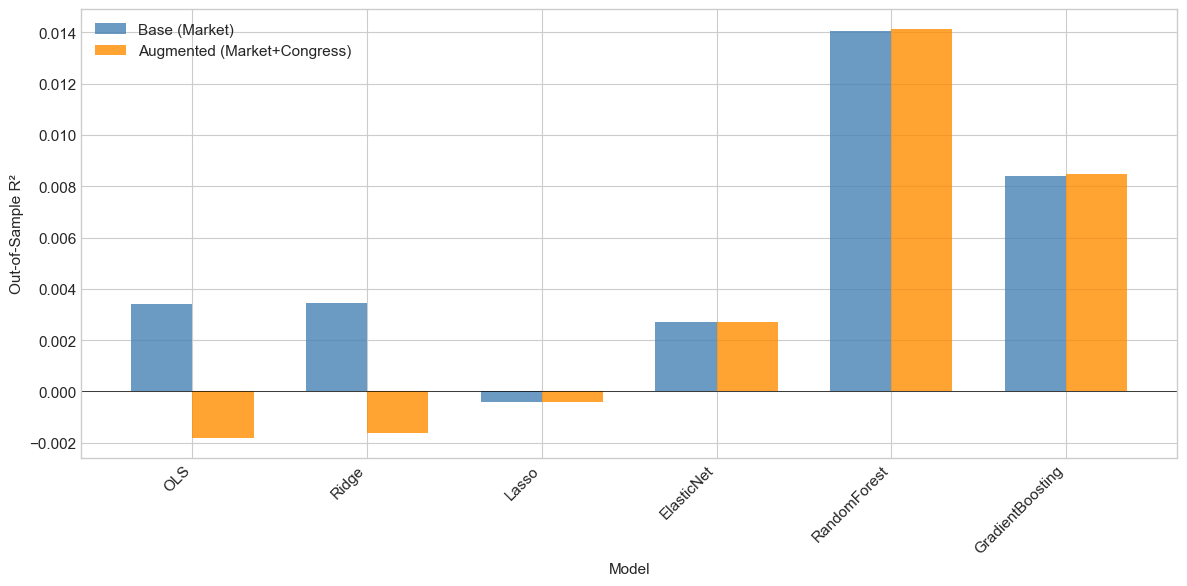

In [23]:
print("\n[11] CREATING FIGURES...")

# Fig 1: R² Comparison
fig, ax = plt.subplots(figsize=(12, 6))
models_list = list(MODELS.keys())
x = np.arange(len(models_list))
width = 0.35

r2_base = [r2_pivot.loc[m, 'Base'] for m in models_list]
r2_aug = [r2_pivot.loc[m, 'Augmented'] for m in models_list]

ax.bar(x - width/2, r2_base, width, label='Base (Market)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, r2_aug, width, label='Augmented (Market+Congress)', color='darkorange', alpha=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('Out-of-Sample R²')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_r2_comparison.png', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/fig1_r2_comparison.pdf')
plt.show()

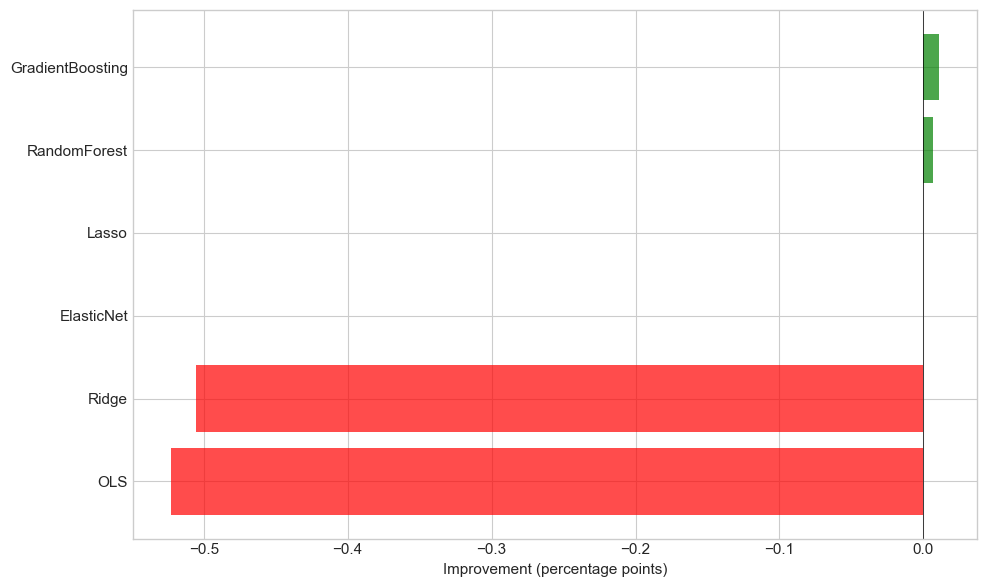

In [24]:
# Fig 2: Improvement
fig, ax = plt.subplots(figsize=(10, 6))
impr = r2_pivot['Improvement_pp'].sort_values()
colors = ['green' if x > 0 else 'red' for x in impr]
ax.barh(impr.index, impr.values, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Improvement (percentage points)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_improvement.png', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/fig2_improvement.pdf')
plt.show()

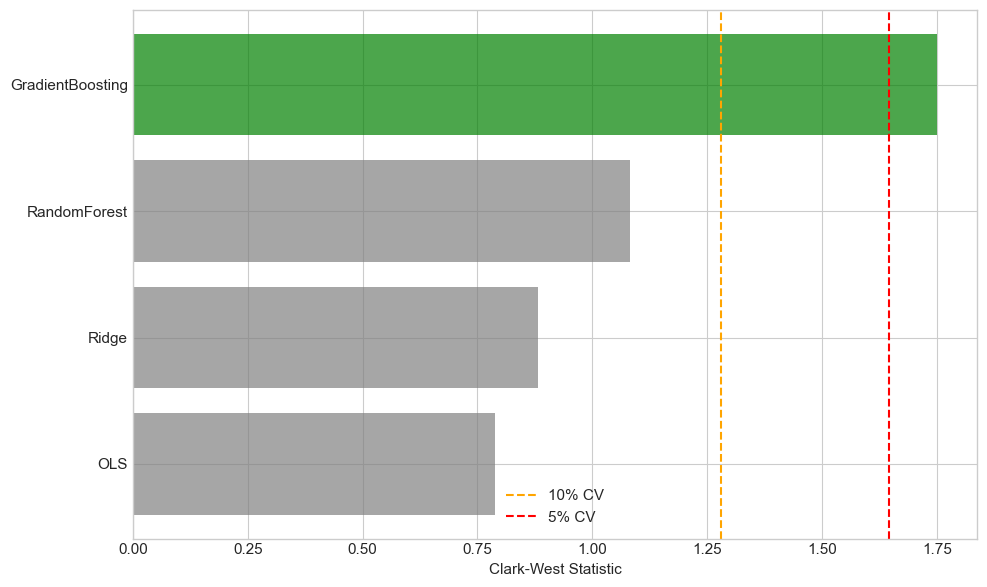

In [25]:
# Fig 3: Clark-West
fig, ax = plt.subplots(figsize=(10, 6))
cw_sort = cw_df.sort_values('CW_Stat')
colors = ['green' if p < 0.05 else 'orange' if p < 0.10 else 'gray' for p in cw_sort['p_value']]
ax.barh(cw_sort['Model'], cw_sort['CW_Stat'], color=colors, alpha=0.7)
ax.axvline(x=1.28, color='orange', linestyle='--', label='10% CV')
ax.axvline(x=1.645, color='red', linestyle='--', label='5% CV')
ax.set_xlabel('Clark-West Statistic')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_clark_west.png', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/fig3_clark_west.pdf')
plt.show()

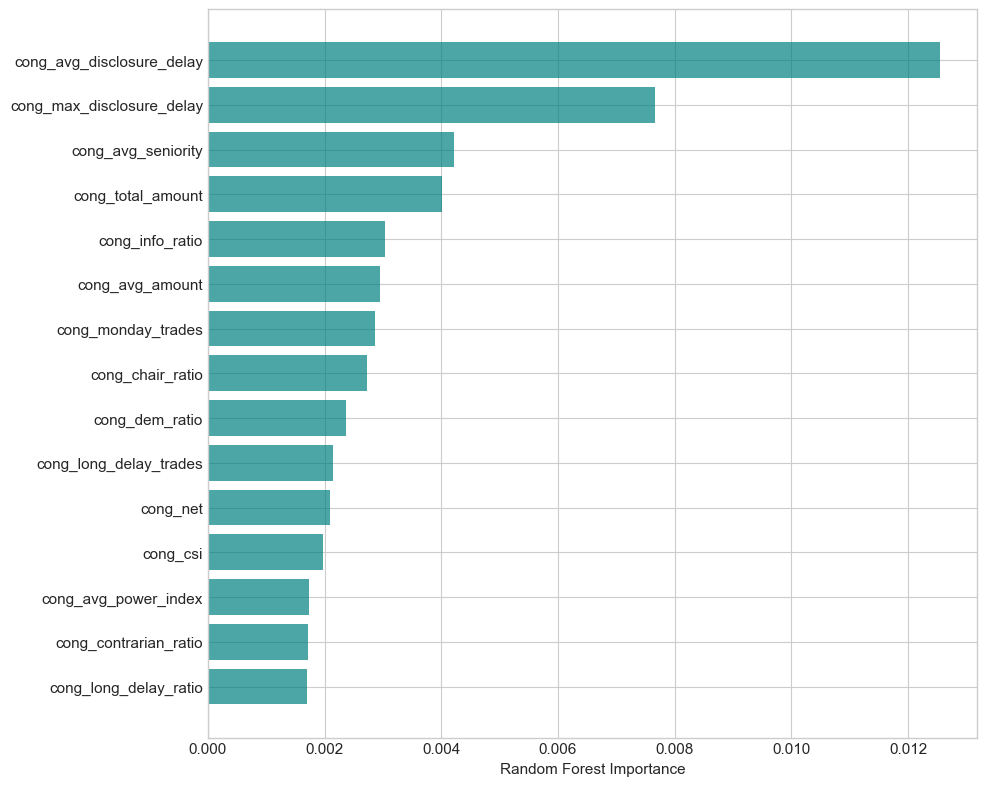

In [26]:
# Fig 4: Congress Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
rf_top = rf_cong.head(15).sort_values('Importance')
ax.barh(rf_top['Feature'], rf_top['Importance'], color='teal', alpha=0.7)
ax.set_xlabel('Random Forest Importance')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_feature_importance.png', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/fig4_feature_importance.pdf')
plt.show()

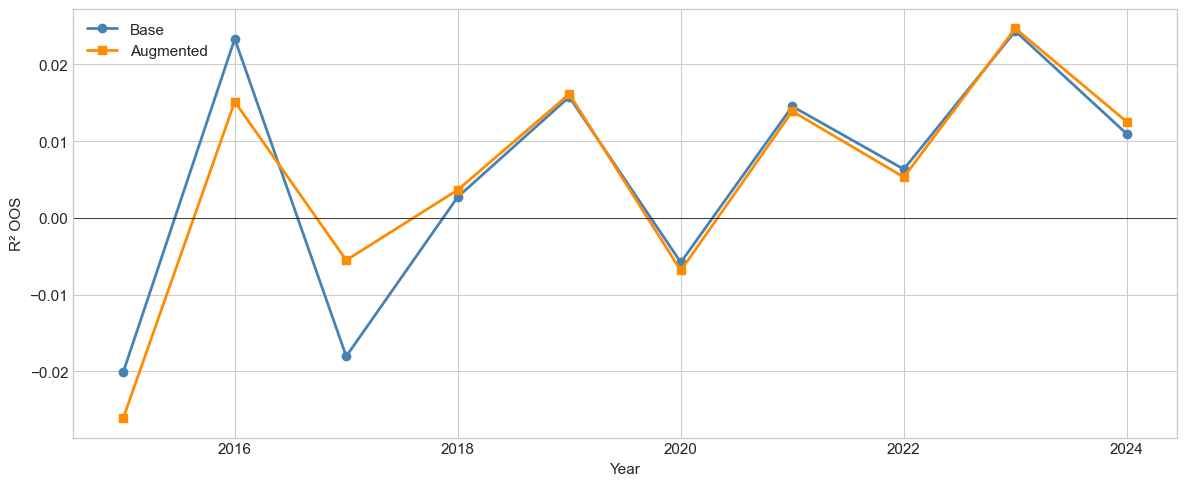

In [27]:
# Fig 5: Temporal
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_df['Year'], yearly_df['R2_Base'], 'o-', label='Base', color='steelblue', linewidth=2)
ax.plot(yearly_df['Year'], yearly_df['R2_Aug'], 's-', label='Augmented', color='darkorange', linewidth=2)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('R² OOS')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_temporal.png', dpi=150)
plt.savefig(f'{OUTPUT_DIR}/fig5_temporal.pdf')
plt.show()

## 12. Export Results

In [29]:
print("\n[12] EXPORTING...")

metrics_df.to_csv(f'{OUTPUT_DIR}/metrics_all.csv', index=False)
r2_pivot.to_csv(f'{OUTPUT_DIR}/r2_comparison.csv')
cw_df.to_csv(f'{OUTPUT_DIR}/clark_west_tests.csv', index=False)
lasso_coefs.to_csv(f'{OUTPUT_DIR}/lasso_coefficients.csv', index=False)
rf_imp.to_csv(f'{OUTPUT_DIR}/rf_feature_importance.csv', index=False)
sg_df.to_csv(f'{OUTPUT_DIR}/subgroup_analysis.csv', index=False)
yearly_df.to_csv(f'{OUTPUT_DIR}/yearly_r2.csv', index=False)

with open(f'{OUTPUT_DIR}/feature_sets_used.json', 'w') as f:
    json.dump({'market': FEATURES_MARKET, 'congress': FEATURES_CONGRESS, 
               'congress_core': FEATURES_CONGRESS_CORE, 'target': TARGET}, f, indent=2)

print(f"Files saved to {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  - {f}")


[12] EXPORTING...
Files saved to Model_1/
  - clark_west_tests.csv
  - feature_sets_used.json
  - fig1_r2_comparison.pdf
  - fig1_r2_comparison.png
  - fig2_improvement.pdf
  - fig2_improvement.png
  - fig3_clark_west.pdf
  - fig3_clark_west.png
  - fig4_feature_importance.pdf
  - fig4_feature_importance.png
  - fig5_temporal.pdf
  - fig5_temporal.png
  - lasso_coefficients.csv
  - metrics_all.csv
  - r2_comparison.csv
  - rf_feature_importance.csv
  - subgroup_analysis.csv
  - yearly_r2.csv


## 13. Conclusions

In [30]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

best_base = r2_pivot['Base'].max()
best_aug = r2_pivot['Augmented'].max()
avg_impr = r2_pivot['Improvement_pp'].mean()
n_improved = (r2_pivot['Improvement_pp'] > 0).sum()
n_cw_sig = (cw_df['p_value'] < 0.10).sum()

print(f"""
DATA:
  Observations: {len(df):,}
  Period: {df['month_dt'].min().strftime('%Y-%m')} - {df['month_dt'].max().strftime('%Y-%m')}
  Target: {TARGET}

PERFORMANCE:
  Best Base R²: {best_base:.4f}
  Best Augmented R²: {best_aug:.4f}
  Models improved: {n_improved}/{len(MODELS)}
  Avg improvement: {avg_impr:.2f} pp

STATISTICAL TESTS:
  Clark-West sig (10%): {n_cw_sig}/{len(MODELS)}
  Clark-West sig (5%): {(cw_df['p_value'] < 0.05).sum()}/{len(MODELS)}

TOP CONGRESS FEATURES:
""")
for _, row in rf_cong.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*70)
if avg_impr > 0 and n_cw_sig > 0:
    print("CONCLUSION: Congressional features IMPROVE prediction of abnormal returns.")
    print("This is consistent with trades containing private information.")
else:
    print("CONCLUSION: No significant improvement from congressional features.")
print("="*70)


SUMMARY

DATA:
  Observations: 34,623
  Period: 2012-07 - 2024-12
  Target: ret_future_car30_ff3

PERFORMANCE:
  Best Base R²: 0.0141
  Best Augmented R²: 0.0141
  Models improved: 2/6
  Avg improvement: -0.17 pp

STATISTICAL TESTS:
  Clark-West sig (10%): 1/6
  Clark-West sig (5%): 1/6

TOP CONGRESS FEATURES:

  cong_avg_disclosure_delay: 0.0126
  cong_max_disclosure_delay: 0.0077
  cong_avg_seniority: 0.0042
  cong_total_amount: 0.0040
  cong_info_ratio: 0.0030

CONCLUSION: No significant improvement from congressional features.
